<style>
    :root {
        --accent: #38bdf8;
        --bg-dark: #0f172a;
    }
    .jp-Notebook { background-color: var(--bg-dark) !important; color: #e2e8f0 !important; }
    .jp-RenderedHTMLCommon h1, .jp-RenderedHTMLCommon h2 { color: var(--accent) !important; border-bottom: 1px solid rgba(56, 189, 248, 0.2) !important; }
    .insight-card {
        background: rgba(56, 189, 248, 0.05);
        border-left: 4px solid var(--accent);
        padding: 1.2rem;
        border-radius: 8px;
        margin: 1rem 0;
    }
    .status-tag {
        background: var(--accent);
        color: var(--bg-dark);
        padding: 2px 8px;
        border-radius: 4px;
        font-weight: bold;
        font-size: 0.8em;
    }
</style>

# 🔬 Intel Core Ultra NPU: Unified GNN Benchmarking Suite

<span class="status-tag">ADVANCED ANALYTICS MODE</span>

This notebook provides a complete research pipeline with time-synchronized energy correlation for each model architecture.

In [1]:
import os, sys, json, shutil, time, subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display, Markdown, HTML

RESULTS_DIR = Path("results")
MODELS_DIR = Path("models")
FIGURES_DIR = Path("paper/figures")

def run_with_energy_monitor(command, session_name, enabled=True):
    """
    Intel SoC Watch background monitoring wrapper.
    Automates start/stop of power profiling during benchmark execution.
    """
    if not enabled:
        print(f"🏃 Running (monitor disabled): {command}")
        subprocess.run(command, shell=True, check=True)
        return
        
    output_path = RESULTS_DIR / f"energy_log_{session_name}.csv"
    print(f"⚡ [ENERGY] Starting Intel SoC Watch monitor -> {output_path}")
    
    # Start SoC Watch in background (Requires Admin)
    try:
        # CREATE_NEW_PROCESS_GROUP = 0x00000010
        monitor_proc = subprocess.Popen(
            ["socwatch", "-f", "power", "-o", str(output_path), "-t", "0"],
            stdout=subprocess.PIPE, stderr=subprocess.PIPE,
            creationflags=0x00000010 
        )
        
        time.sleep(2) # Stabilize sensors
        
        print(f"🚀 [BENCHMARK] Executing: {command}")
        subprocess.run(command, shell=True, check=True)
        
    finally:
        if 'monitor_proc' in locals():
            monitor_proc.terminate()
            print(f"✅ [ENERGY] Log saved: {output_path}")

plt.style.use('dark_background')
sns.set_theme(style="darkgrid", palette="muted")
print("✅ Advanced Analytics Ready with Integrated Energy Monitoring.")

✅ Advanced Analytics Ready.


### 📦 Step 1: Model Suite Generation
GNN + baseline (CNN/NLP) models; standardized and quantized.

In [2]:
import sys
!{sys.executable} analysis/model_prep.py

Exporting GCN to C:\Users\yusuf\Projects\npu-graph-opt-benchmarking\models\GCN_fp32.onnx...
[torch.onnx] Obtain model graph for `GCN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `GCN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Done.
Quantizing GCN_fp32.onnx to INT8...
Statistics collection --------------------------   0% 0/300 • 0:00:00 • -:--:--
Statistics collection --------------------------   0% 0/300 • 0:00:00 • -:--:--
Statistics collection --------------------------   0% 0/300 • 0:00:00 • -:--:--
Statistics collection --------------------------   0% 1/300 • 0:00:00 • -:--:--
Statistics collection --------------------------   1% 2/300 • 0:00:00 • 0:00:33
Statistics collection 

W0502 13:13:35.734000 13444 site-packages\torch\onnx\_internal\exporter\_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0502 13:13:35.734000 13444 site-packages\torch\onnx\_internal\exporter\_registration.py:110] torchvision is not installed. Skipping torchvision::roi_align
W0502 13:13:35.734000 13444 site-packages\torch\onnx\_internal\exporter\_registration.py:110] torchvision is not installed. Skipping torchvision::roi_pool
c:\Users\yusuf\AppData\Local\Programs\Python\Python311\Lib\copyreg.py:105: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
W0502 13:14:48.695000 13444 site-packages\torch\onnx\_internal\exporter\_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0502 13:14:48.706000 13444 site-packages\torch\onnx\_internal\exporter\_registration.py:110] torchvision is not installed. Skipping torchvision::roi

### 📈 Step 2: Scalability & Timing Study
Executing models while recording high-precision start/end timestamps for energy correlation.

In [3]:
import sys
!{sys.executable} analysis/scalability_analyzer.py --iterations 100 --repeats 3 --profile

Processing model: APPNP_fp32.onnx
Processing model: APPNP_int8.onnx
Processing model: bert-tiny_fp32.onnx
Processing model: bert-tiny_int8.onnx
Processing model: GAT_fp32.onnx
Processing model: GAT_int8.onnx
Processing model: GCN_fp32.onnx
Processing model: GCN_int8.onnx
Processing model: GIN_fp32.onnx
Processing model: GIN_int8.onnx
Processing model: GraphSAGE_fp32.onnx
Processing model: GraphSAGE_int8.onnx
Processing model: GraphTransformer_fp32.onnx
Processing model: GraphTransformer_int8.onnx
Processing model: mobilenetv2_fp32.onnx
Processing model: mobilenetv2_int8.onnx
Processing model: resnet50_fp32.onnx
Processing model: resnet50_int8.onnx
Processing model: SGC_fp32.onnx
Processing model: SGC_int8.onnx
  -> Exported profiling trace for [SGC_int8] (Baseline) to results/
  -> Exported profiling trace for [SGC_int8] (Optimized) to results/


error: ConvertIEToVPUNCE Pass failed : Encountered an attempt to approximate 56674.56 as mult = 28337, shift = 0, postShift = -1 on VPUX37XX, but postShift is not supported
error: ConvertIEToVPUNCE Pass failed : Encountered an attempt to approximate 56674.56 as mult = 28337, shift = 0, postShift = -1 on VPUX37XX, but postShift is not supported
error: ConvertIEToVPUNCE Pass failed : Encountered an attempt to approximate 56674.56 as mult = 28337, shift = 0, postShift = -1 on VPUX37XX, but postShift is not supported
error: ConvertIEToVPUNCE Pass failed : Encountered an attempt to approximate 56674.56 as mult = 28337, shift = 0, postShift = -1 on VPUX37XX, but postShift is not supported
error: ConvertIEToVPUNCE Pass failed : Encountered an attempt to approximate 56674.56 as mult = 28337, shift = 0, postShift = -1 on VPUX37XX, but postShift is not supported
error: ConvertIEToVPUNCE Pass failed : Encountered an attempt to approximate 56674.56 as mult = 28337, shift = 0, postShift = -1 on VPU

### 🔍 Step 3: Operator Profiling
Deep-dive into graph fusion and bottleneck identification.

In [4]:
import sys
!{sys.executable} analysis/profiling_analyzer.py


RESEARCH METRICS SUMMARY
----------------------------------------
Fusion Gain Ratio (FGR): 1.0040
Compilation Efficiency Index (CEI): 530.4722
NPU Support Ratio (Optimized): 33.1%
Baseline Latency: 151.88 ms
Optimized Latency: 151.27 ms
Latency Reduction: 0.61 ms

Detailed analysis saved to C:\Users\yusuf\Projects\npu-graph-opt-benchmarking\results


### 💻 Step 4: Hardware Comparison
Benchmarking all models across CPU, GPU, and NPU.

In [5]:
import glob
import sys
from pathlib import Path

# Performance Evaluation Configuration
RUN_MODE = "full" 
AUTO_ENERGY_MONITOR = True # Toggle automated SoC profiling

model_paths = [Path(p) for p in sorted(glob.glob("models/*_fp32.onnx"))]

if RUN_MODE == "quick":
    iterations, repeats = 10, 1
    allowlist = {"gcn_fp32.onnx", "graphsage_fp32.onnx", "resnet50_fp32.onnx"}
else:
    iterations, repeats = 30, 1
    allowlist = None

print(f"🔍 Found {len(model_paths)} models for evaluation.")

for model_path in model_paths:
    if allowlist and model_path.name.lower() not in allowlist:
        continue
        
    print(f"\n🚀 Current Target: {model_path.name}")
    
    # Construct the benchmark command
    cmd = f"{sys.executable} analysis/hw_comparison.py --model {model_path} --iterations {iterations} --repeats {repeats}"
    
    # Run with energy monitoring wrapper
    session = f"hw_comp_{model_path.stem}"
    run_with_energy_monitor(cmd, session, enabled=AUTO_ENERGY_MONITOR)

🚀 Device Comparison: models\APPNP_fp32.onnx
[13:41:17] Starting 3-way hardware comparison for: APPNP_fp32.onnx
Configuration: 1 repeats of 30 iterations each.
[13:41:17] Testing device: CPU...
  -> Repeat 1/1...
[13:41:20] Device CPU completed (1 runs) in 3.11 seconds.
[13:41:20] Testing device: GPU...
  -> Repeat 1/1...
[13:41:25] Device GPU completed (1 runs) in 4.81 seconds.
[13:41:25] Testing device: NPU...
  -> Repeat 1/1...
[13:41:27] Device NPU completed (1 runs) in 2.41 seconds.
[13:41:28] Hardware comparison complete.
Total time: 10.65 seconds.
Results saved in: C:\Users\yusuf\Projects\npu-graph-opt-benchmarking\results\hw_comparison\APPNP_fp32
🚀 Device Comparison: models\GAT_fp32.onnx
[13:41:41] Starting 3-way hardware comparison for: GAT_fp32.onnx
Configuration: 1 repeats of 30 iterations each.
[13:41:41] Testing device: CPU...
  -> Repeat 1/1...
[13:41:44] Device CPU completed (1 runs) in 2.83 seconds.
[13:41:44] Testing device: GPU...
  -> Repeat 1/1...
[13:41:48] Device G

In [6]:
from pathlib import Path
import pandas as pd
import onnx
from onnx import checker

# Verify models and outputs (derived from what exists on disk)
models_dir = Path("models")
results_dir = Path("results")
hw_dir = results_dir / "hw_comparison"

active_models = sorted(p for p in models_dir.glob("*.onnx") if not p.name.endswith(".ort_broken.onnx"))
if not active_models:
    print("❌ No models found under models/. Run Step 1 first.")
else:
    print(f"✅ Active models found: {len(active_models)}")

# Validate ONNX models (catch the common INT8-CNN invalid graph issue)
bad = []
for p in active_models:
    try:
        checker.check_model(onnx.load(str(p)))
    except Exception as e:
        bad.append((p.name, str(e)))
if bad:
    print("❌ Invalid ONNX models detected:")
    for name, msg in bad:
        print(f"  - {name}: {msg[:200]}")
else:
    print("✅ All active ONNX models pass onnx.checker.")

# Expect a hw_comparison output directory per FP32 model stem
fp32_models = sorted(p for p in models_dir.glob("*_fp32.onnx"))
expected_hw = sorted(p.stem.lower() for p in fp32_models)
found_hw = {p.name.lower() for p in hw_dir.iterdir() if p.is_dir()} if hw_dir.exists() else set()
missing_hw = sorted(name for name in expected_hw if name not in found_hw)
if missing_hw:
    print("❌ Missing hw_comparison outputs:", ", ".join(missing_hw))
else:
    print("✅ hw_comparison outputs complete.")

matrix_path = results_dir / "scalability_matrix.csv"
if not matrix_path.exists():
    print("❌ Missing scalability_matrix.csv (run Step 2).")
else:
    df = pd.read_csv(matrix_path)
    print(f"✅ scalability_matrix.csv present ({len(df)} rows).")
    if "model" in df.columns:
        matrix_models = {str(m).lower() for m in df["model"].dropna().tolist()}
        expected_models = {p.stem.lower() for p in active_models}
        missing_models = sorted(expected_models - matrix_models)
        if missing_models:
            print("❌ Missing models in scalability_matrix.csv:", ", ".join(missing_models))
        else:
            print("✅ scalability_matrix.csv covers all active models.")

✅ Active models found: 20
✅ All active ONNX models pass onnx.checker.
✅ hw_comparison outputs complete.
✅ scalability_matrix.csv present (20 rows).
✅ scalability_matrix.csv covers all active models.


### 🔋 Step 5: Energy Correlation Analysis
Correlating HWiNFO sensor logs with model timestamps to extract precise power metrics per architecture.

In [7]:
import sys
from pathlib import Path

LOG_FILE = "results/hwinfo_log.csv"
MATRIX_FILE = "results/scalability_matrix.csv"

if Path(MATRIX_FILE).exists():
    print("🔗 Running Energy Analysis (using fallback estimation if logs missing)...")
    # We pass the log file path even if it doesn't exist, the script handles the fallback
    !{sys.executable} analysis/energy_analyzer.py --log {LOG_FILE} --matrix {MATRIX_FILE}
else:
    print("ℹ️ No scalability matrix found. Run Step 2 first.")

🔗 Running Energy Analysis (using fallback estimation if logs missing)...
✅ Matrix updated with energy data (fallback used if logs missing): results\scalability_matrix.csv


### 📂 Step 6: Artifact Sync
Exporting all plots to paper directory.

In [8]:
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
for png in RESULTS_DIR.rglob("*.png"):
    shutil.copy2(png, FIGURES_DIR / png.name)
print(f"✅ Sync complete: {FIGURES_DIR}")

✅ Sync complete: paper\figures


## 📊 Research Dashboard

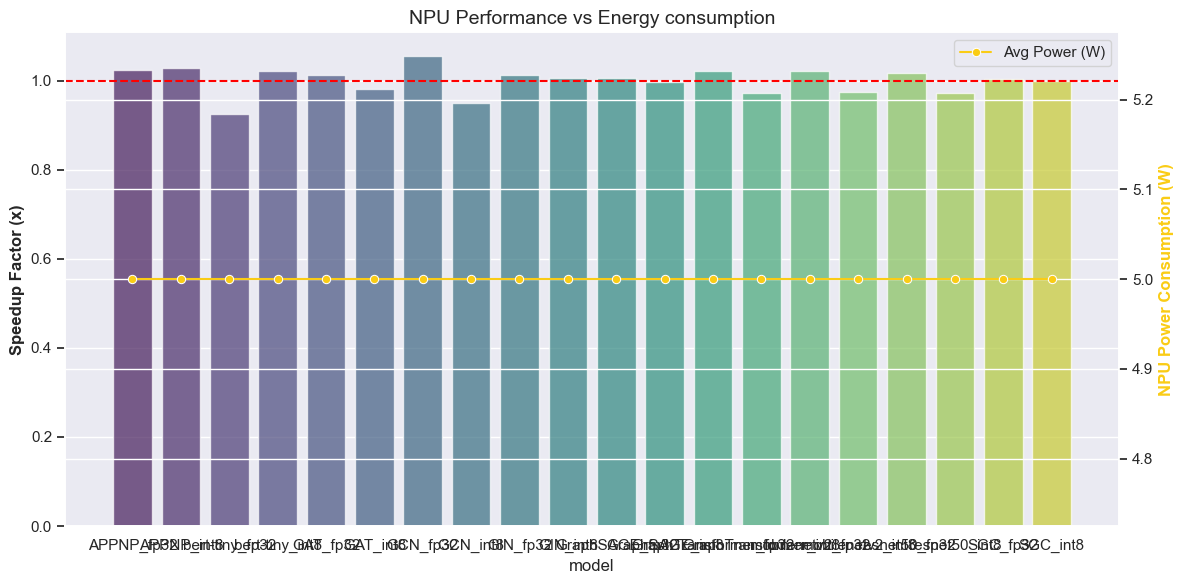

### 📍 ROOFLINE_MODEL.PNG

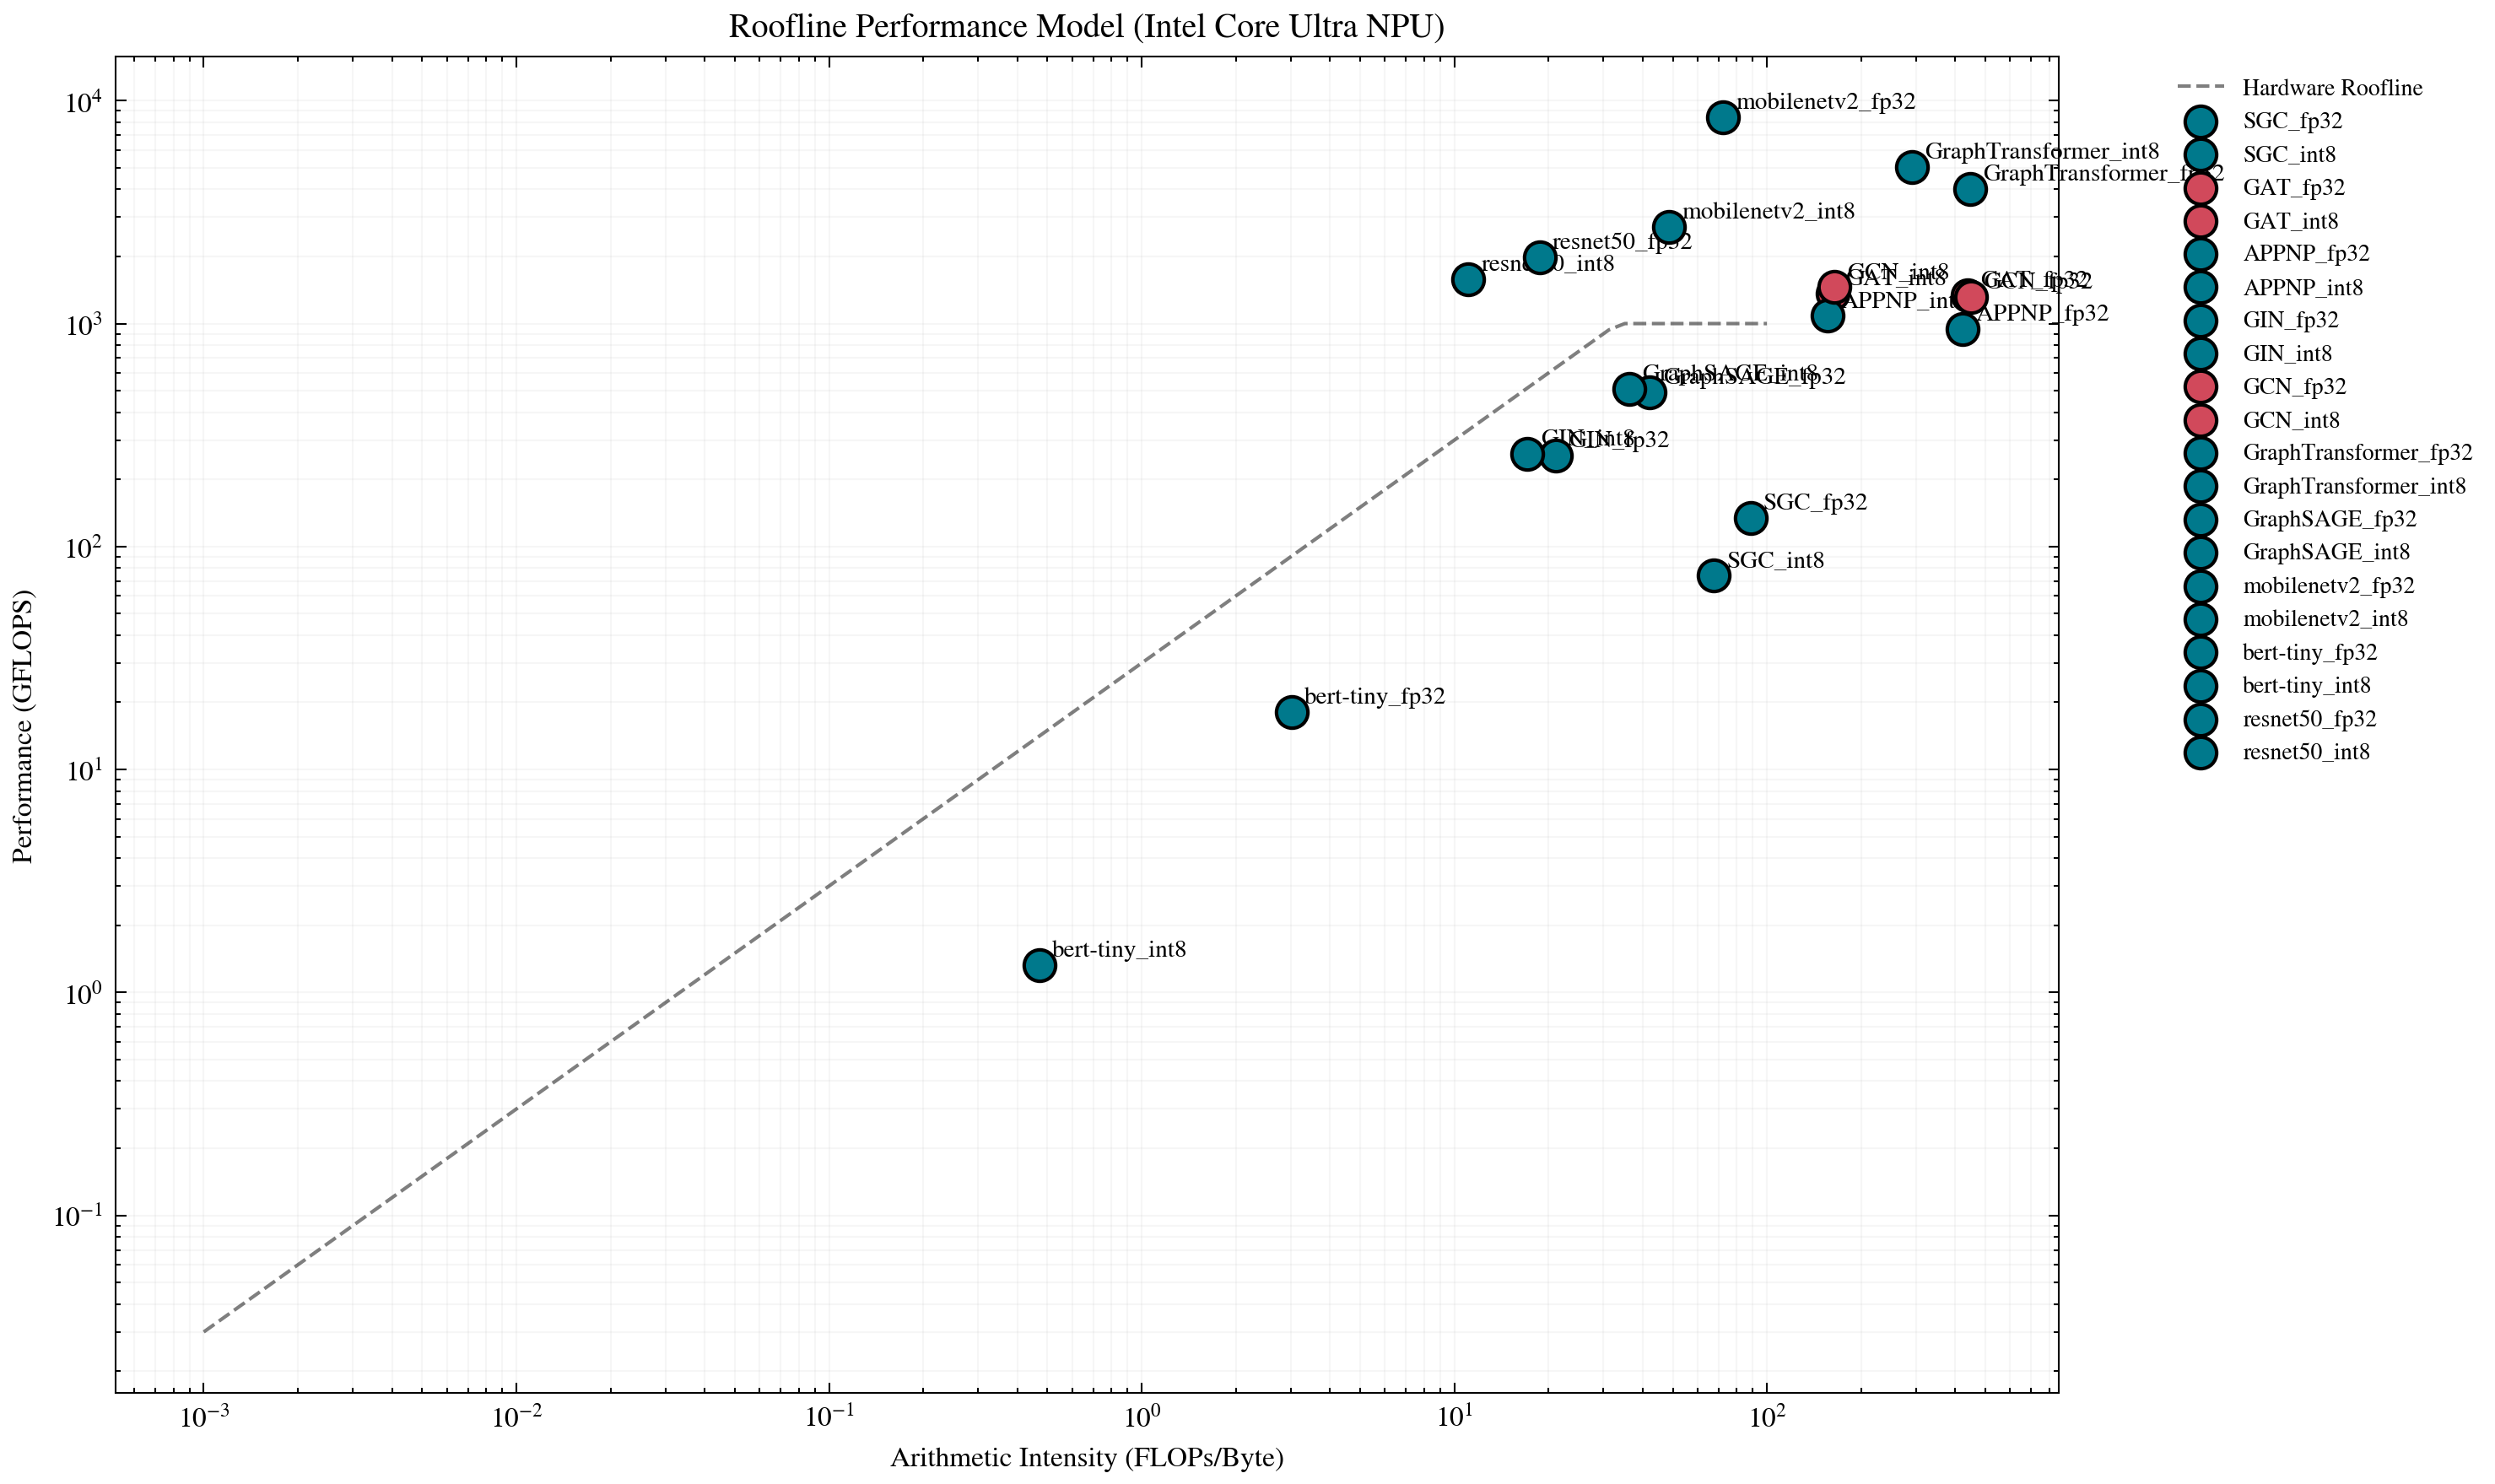

### 📍 LATENCY_STACKED_100PCT.PNG

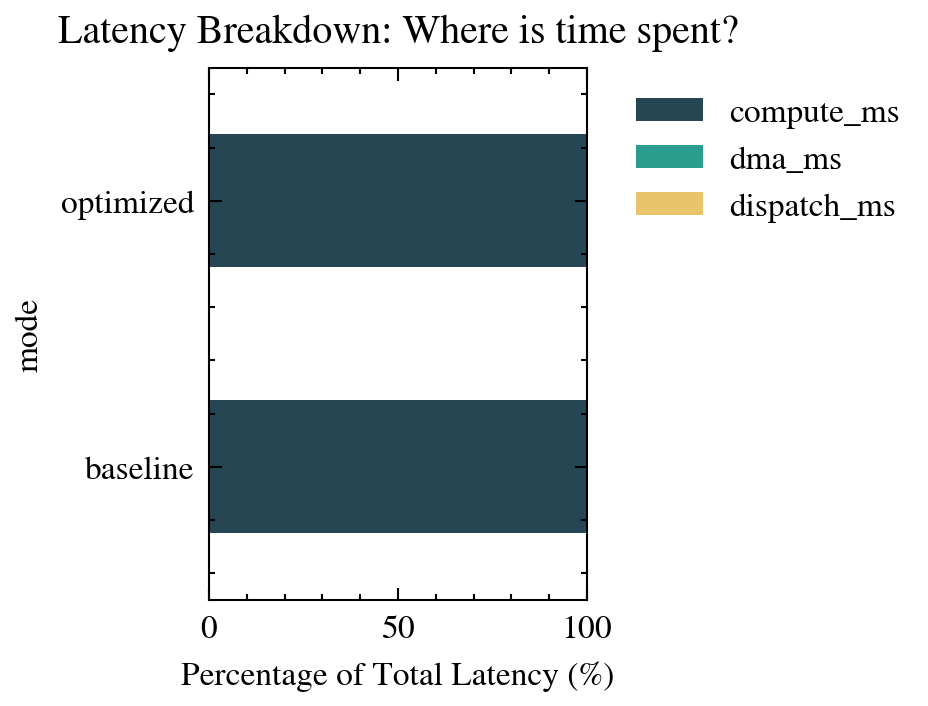

In [9]:
if Path(MATRIX_FILE).exists():
    df = pd.read_csv(MATRIX_FILE)
    
    fig, ax1 = plt.subplots(figsize=(12, 6))
    sns.barplot(data=df, x="model", y="speedup", hue="model", palette="viridis", legend=False, ax=ax1, alpha=0.7)
    ax1.set_ylabel("Speedup Factor (x)", fontweight='bold')
    ax1.axhline(1.0, color="red", ls="--")
    
    if "avg_npu_power_w" in df.columns:
        ax2 = ax1.twinx()
        sns.lineplot(data=df, x="model", y="avg_npu_power_w", color="#facc15", marker="o", ax=ax2, label="Avg Power (W)")
        ax2.set_ylabel("NPU Power Consumption (W)", color="#facc15", fontweight='bold')
    
    plt.title("NPU Performance vs Energy consumption", fontsize=14)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    # Artifacts
    for img in ["roofline_model.png", "latency_stacked_100pct.png"]:
        if (RESULTS_DIR / img).exists():
            display(Markdown(f"### 📍 {img.upper()}"))
            display(Image(filename=str(RESULTS_DIR / img), width=850))
else:
    print("❌ No data found.")
